##               **RESUME SCREENING PROJECT**




In [544]:
# Importing the data sets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


  ## **Upload The Dataset**



In [545]:
df = pd.read_csv("ai_resume_screening.csv")
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes


In [546]:
df.shape

(30000, 7)

In [547]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [548]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [549]:
df.tail()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes
29999,14,77.3,Masters,25,694,790,Yes


In [550]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [551]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


         
 #       **Data Cleaning**

In [552]:
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [553]:
df.duplicated().sum()

np.int64(0)

#      **Exploratory Data Analysis**

In [554]:
df['shortlisted'].value_counts()

,count
shortlisted,
Yes,20966
No,9034


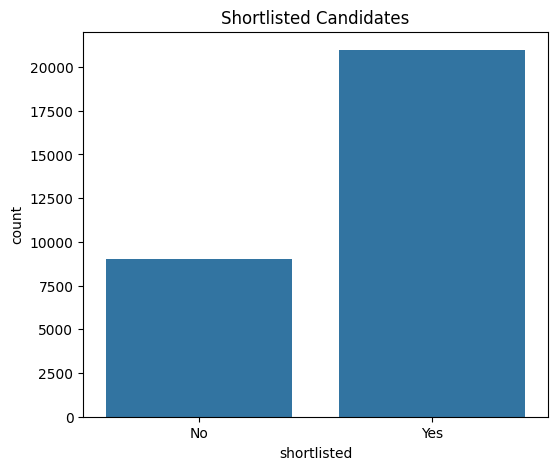

In [555]:
# To show the count of shortlisted candidates
plt.figure(figsize=(6,5))

sns.countplot(x='shortlisted',data=df)

plt.title("Shortlisted Candidates")
plt.show()

In [556]:
x=df["education_level"].value_counts()
x

,count
education_level,
Bachelors,13461
Masters,10524
PhD,3024
High School,2991


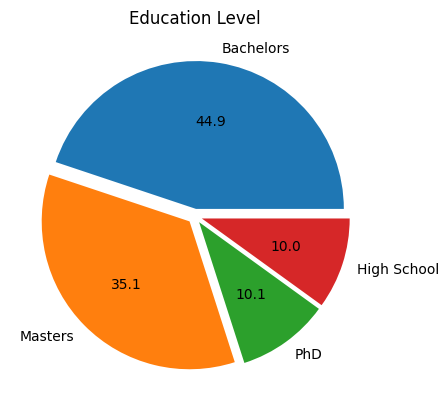

In [557]:
# Education level
plt.pie(x,labels=x.index,autopct='%1.1f',explode=[0.05,0.05,0.05,0.05])

plt.title("Education Level")
plt.show()

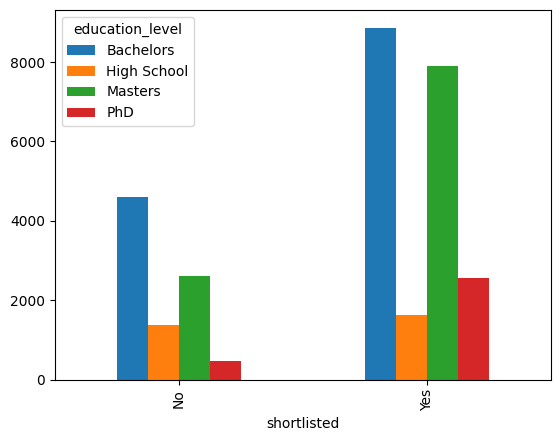

In [558]:
#shortlisted based on the Education Level

pd.crosstab(df["shortlisted"],df["education_level"]).plot(kind="bar")
plt.show()

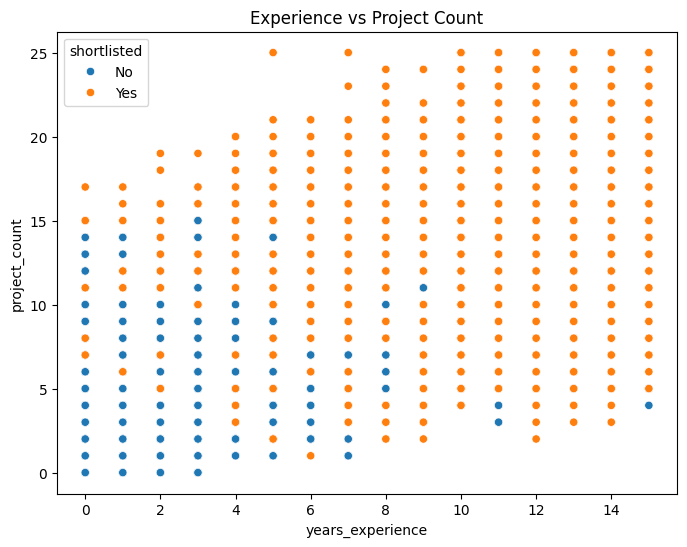

In [559]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='years_experience',
    y='project_count',
    hue='shortlisted',
    data=df
)

plt.title("Experience vs Project Count")
plt.show()

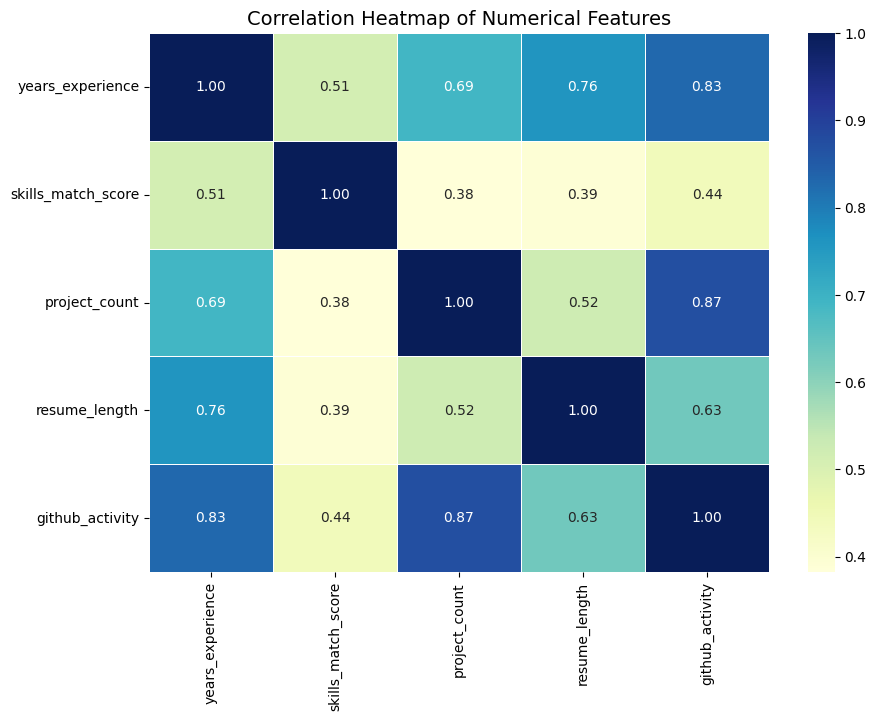

In [560]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5,
            fmt='.2f')

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

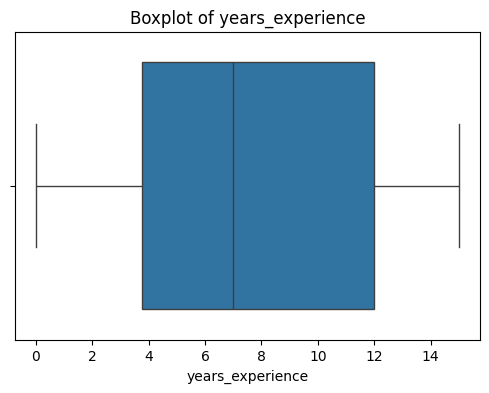

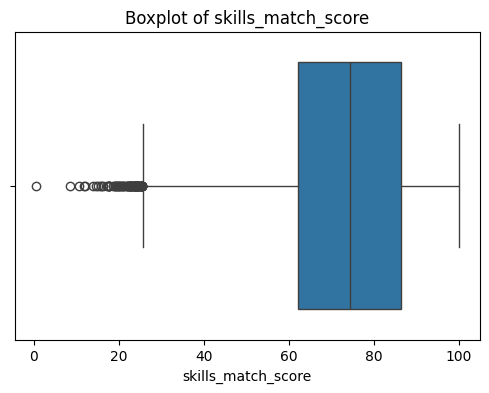

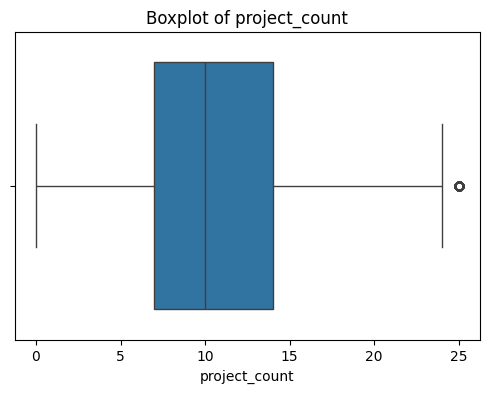

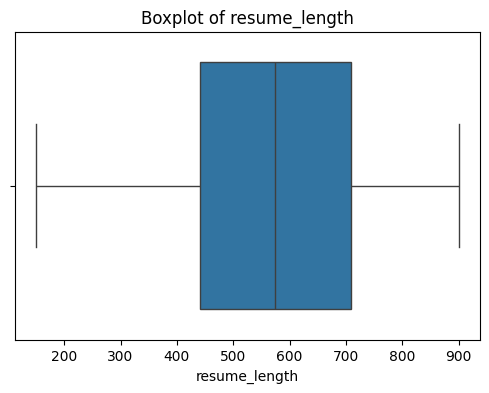

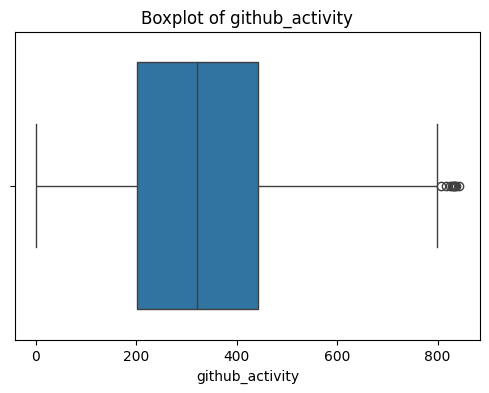

In [561]:
numerical_columns = [
    'years_experience',
    'skills_match_score',
    'project_count',
    'resume_length',
    'github_activity'
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

#One Hot Encoding

In [562]:
from sklearn.preprocessing import OneHotEncoder

In [563]:
oe=OneHotEncoder()

In [564]:
df=pd.get_dummies(df,columns=["education_level"],drop_first=True)


In [565]:
df

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,No,False,False,False
1,3,59.1,5,502,77,No,False,True,False
2,12,100.0,12,753,381,Yes,False,True,False
3,14,66.8,8,529,407,Yes,True,False,False
4,10,99.6,10,754,331,Yes,False,False,False
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,Yes,False,False,False
29996,5,77.8,9,473,149,No,False,False,False
29997,1,64.6,7,247,82,No,False,False,False
29998,7,94.8,12,584,409,Yes,False,False,False


# Label Encoding




In [566]:
from sklearn.preprocessing import LabelEncoder


In [567]:
le = LabelEncoder()

In [568]:
df["shortlisted"]=le.fit_transform(df["shortlisted"])
df
# No--->0
# Yes--->1

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,False,False,False
1,3,59.1,5,502,77,0,False,True,False
2,12,100.0,12,753,381,1,False,True,False
3,14,66.8,8,529,407,1,True,False,False
4,10,99.6,10,754,331,1,False,False,False
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,1,False,False,False
29996,5,77.8,9,473,149,0,False,False,False
29997,1,64.6,7,247,82,0,False,False,False
29998,7,94.8,12,584,409,1,False,False,False


In [569]:
df["education_level_High School"]=le.fit_transform(df["education_level_High School"])
df

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,0,False,False
1,3,59.1,5,502,77,0,0,True,False
2,12,100.0,12,753,381,1,0,True,False
3,14,66.8,8,529,407,1,1,False,False
4,10,99.6,10,754,331,1,0,False,False
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,1,0,False,False
29996,5,77.8,9,473,149,0,0,False,False
29997,1,64.6,7,247,82,0,0,False,False
29998,7,94.8,12,584,409,1,0,False,False


In [570]:
df["education_level_Masters"]=le.fit_transform(df["education_level_Masters"])
df

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,0,0,False
1,3,59.1,5,502,77,0,0,1,False
2,12,100.0,12,753,381,1,0,1,False
3,14,66.8,8,529,407,1,1,0,False
4,10,99.6,10,754,331,1,0,0,False
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,1,0,0,False
29996,5,77.8,9,473,149,0,0,0,False
29997,1,64.6,7,247,82,0,0,0,False
29998,7,94.8,12,584,409,1,0,0,False


In [571]:
df["education_level_PhD"]=le.fit_transform(df["education_level_PhD"])
df

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,0,0,0
1,3,59.1,5,502,77,0,0,1,0
2,12,100.0,12,753,381,1,0,1,0
3,14,66.8,8,529,407,1,1,0,0
4,10,99.6,10,754,331,1,0,0,0
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,1,0,0,0
29996,5,77.8,9,473,149,0,0,0,0
29997,1,64.6,7,247,82,0,0,0,0
29998,7,94.8,12,584,409,1,0,0,0


In [572]:
from sklearn.preprocessing import StandardScaler

In [573]:
scaler=StandardScaler()

In [574]:
df["years_experience"]=scaler.fit_transform(df[["years_experience"]])
df["skills_match_score"]=scaler.fit_transform(df[["skills_match_score"]])
df["project_count"]=scaler.fit_transform(df[["project_count"]])
df["resume_length"]=scaler.fit_transform(df[["resume_length"]])
df["github_activity"]=scaler.fit_transform(df[["github_activity"]])
df["education_level_High School"]=scaler.fit_transform(df[["education_level_High School"]])
df["education_level_Masters"]=scaler.fit_transform(df[["education_level_Masters"]])
df["education_level_PhD"]=scaler.fit_transform(df[["education_level_PhD"]])

In [575]:
df

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,-0.325813,0.657139,-0.786856,-1.894637,-1.045712,0,-0.332777,-0.735090,-0.334813
1,-0.974598,-0.869795,-1.218451,-0.394975,-1.552123,0,-0.332777,1.360378,-0.334813
2,0.971758,1.569720,0.292133,1.009560,0.348482,1,-0.332777,1.360378,-0.334813
3,1.404281,-0.410522,-0.571058,-0.243889,0.511033,1,3.005011,-0.735090,-0.334813
4,0.539234,1.545862,-0.139463,1.015155,0.035882,1,-0.332777,-0.735090,-0.334813
...,...,...,...,...,...,...,...,...,...
29995,0.322972,0.221724,0.507930,0.662623,0.679837,1,-0.332777,-0.735090,-0.334813
29996,-0.542074,0.245583,-0.355261,-0.557251,-1.101979,0,-0.332777,-0.735090,-0.334813
29997,-1.407121,-0.541742,-0.786856,-1.821892,-1.520863,0,-0.332777,-0.735090,-0.334813
29998,-0.109551,1.259562,0.292133,0.063877,0.523537,1,-0.332777,-0.735090,-0.334813


#Seperating the Target column


In [576]:
x=df.drop("shortlisted",axis=1)
x

,years_experience,skills_match_score,project_count,resume_length,github_activity,education_level_High School,education_level_Masters,education_level_PhD
0,-0.325813,0.657139,-0.786856,-1.894637,-1.045712,-0.332777,-0.735090,-0.334813
1,-0.974598,-0.869795,-1.218451,-0.394975,-1.552123,-0.332777,1.360378,-0.334813
2,0.971758,1.569720,0.292133,1.009560,0.348482,-0.332777,1.360378,-0.334813
3,1.404281,-0.410522,-0.571058,-0.243889,0.511033,3.005011,-0.735090,-0.334813
4,0.539234,1.545862,-0.139463,1.015155,0.035882,-0.332777,-0.735090,-0.334813
...,...,...,...,...,...,...,...,...
29995,0.322972,0.221724,0.507930,0.662623,0.679837,-0.332777,-0.735090,-0.334813
29996,-0.542074,0.245583,-0.355261,-0.557251,-1.101979,-0.332777,-0.735090,-0.334813
29997,-1.407121,-0.541742,-0.786856,-1.821892,-1.520863,-0.332777,-0.735090,-0.334813
29998,-0.109551,1.259562,0.292133,0.063877,0.523537,-0.332777,-0.735090,-0.334813


In [577]:
y=df["shortlisted"]
y

,shortlisted
0,0
1,0
2,1
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


In [578]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score


In [579]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


#SMOTE

In [580]:
from imblearn.over_sampling import SMOTE

In [581]:
df['shortlisted'].value_counts()

,count
shortlisted,
1,20966
0,9034


In [582]:
smote=SMOTE(random_state=42)

In [583]:
train_x_smote, train_y_smote = smote.fit_resample(train_x, train_y)

##**Model** **Training**

In [584]:
# IMPORT MACHINE LEARNING ALGORITHMS

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 1. Logistic Regression

In [585]:
lr = LogisticRegression()

In [586]:
lr.fit(train_x_smote, train_y_smote)

LogisticRegression()

In [587]:
lr_pred = lr.predict(test_x)
lr_pred

array([1, 0, 0, ..., 0, 1, 1])

In [588]:
test_y

,shortlisted
3513,1
2980,0
10618,0
21925,0
5145,1
...,...
29843,1
6605,1
21140,0
23323,1


In [589]:
lr_accuracy=accuracy_score(test_y, lr_pred)*100
lr_accuracy


89.2

In [590]:
lr_precision=precision_score(test_y, lr_pred)*100
lr_precision


95.48370541442135

In [591]:
lr_recall=recall_score(test_y, lr_pred)*100
lr_recall


88.7431433341283

In [592]:
lr_f1_score=f1_score(test_y, lr_pred)*100
lr_f1_score

91.99011124845488

In [593]:
print("Accuracy :", accuracy_score(test_y, lr_pred))
print("Precision:", precision_score(test_y, lr_pred))
print("Recall   :", recall_score(test_y, lr_pred))
print("F1 Score :", f1_score(test_y, lr_pred))

print("\nClassification Report")
print(classification_report(test_y, lr_pred))


Accuracy : 0.892
Precision: 0.9548370541442135
Recall   : 0.887431433341283
F1 Score : 0.9199011124845489

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.90      0.83      1807
           1       0.95      0.89      0.92      4193

    accuracy                           0.89      6000
   macro avg       0.87      0.90      0.88      6000
weighted avg       0.90      0.89      0.89      6000



# 2. Decision Tree





In [594]:
dt = DecisionTreeClassifier(criterion="entropy")

In [595]:
dt.fit(train_x_smote, train_y_smote)

DecisionTreeClassifier(criterion='entropy')

In [596]:
dt_pred = dt.predict(test_x)

In [597]:
dt_pred

array([1, 0, 0, ..., 0, 1, 1])

In [598]:
test_y

,shortlisted
3513,1
2980,0
10618,0
21925,0
5145,1
...,...
29843,1
6605,1
21140,0
23323,1


In [599]:
dt_accuracy=accuracy_score(test_y,dt_pred)*100
dt_accuracy

86.46666666666667

In [600]:
dt_precision=precision_score(test_y, dt_pred)*100
dt_precision


90.43291078689309

In [601]:
dt_recall=recall_score(test_y, dt_pred)*100
dt_recall

90.17409968995945

In [602]:
dt_f1_score=f1_score(test_y, dt_pred)*100
dt_f1_score

90.30331979937904

In [603]:
print("Accuracy :", accuracy_score(test_y, dt_pred))
print("Precision:", precision_score(test_y, dt_pred))
print("Recall   :", recall_score(test_y, dt_pred))
print("F1 Score :", f1_score(test_y, dt_pred))

print("\nClassification Report")
print(classification_report(test_y, dt_pred))


Accuracy : 0.8646666666666667
Precision: 0.9043291078689308
Recall   : 0.9017409968995945
F1 Score : 0.9030331979937903

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1807
           1       0.90      0.90      0.90      4193

    accuracy                           0.86      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.86      0.86      0.86      6000



##3. RandomForest

In [604]:
rf = RandomForestClassifier(n_estimators=100)

In [605]:
rf.fit(train_x_smote, train_y_smote)

RandomForestClassifier()

In [606]:
rf_pred=rf.predict(test_x)
rf_pred

array([1, 0, 0, ..., 0, 1, 1])

In [607]:
test_y

,shortlisted
3513,1
2980,0
10618,0
21925,0
5145,1
...,...
29843,1
6605,1
21140,0
23323,1


In [608]:
result = pd.DataFrame({
    "Actual": test_y,
    "Predicted": rf_pred
})

result.head(10)

,Actual,Predicted
3513,1,1
2980,0,0
10618,0,0
21925,0,0
5145,1,1
8823,1,1
10816,1,1
1692,1,1
14769,0,0
8239,1,1


In [609]:
rf_accuracy=accuracy_score(test_y,rf_pred)*100
rf_accuracy

90.10000000000001

In [610]:
rf_precision=precision_score(test_y, rf_pred)*100
rf_precision

93.56088114258048

In [611]:
rf_recall=recall_score(test_y, rf_pred)*100
rf_recall

92.17743858812307

In [612]:
rf_f1_score=f1_score(test_y, rf_pred)*100
rf_f1_score

92.86400768861125

In [613]:
print("Accuracy :", accuracy_score(test_y, rf_pred))
print("Precision:", precision_score(test_y, rf_pred))
print("Recall   :", recall_score(test_y, rf_pred))
print("F1 Score :", f1_score(test_y, rf_pred))

print("\nClassification Report")
print(classification_report(test_y, rf_pred))


Accuracy : 0.901
Precision: 0.9356088114258049
Recall   : 0.9217743858812306
F1 Score : 0.9286400768861125

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1807
           1       0.94      0.92      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.88      0.89      0.88      6000
weighted avg       0.90      0.90      0.90      6000



#4.SVM

In [614]:
svm = SVC(kernel='rbf')

svm.fit(train_x_smote, train_y_smote)

svm_pred = svm.predict(test_x)

svm_accuracy = accuracy_score(test_y, svm_pred)*100
svm_precision = precision_score(test_y, svm_pred)*100
svm_recall = recall_score(test_y, svm_pred)*100
svm_f1_score = f1_score(test_y, svm_pred)*100

print("SVM Accuracy :", svm_accuracy)
print("SVM Precision :", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1_score :", svm_f1_score)

SVM Accuracy : 88.91666666666667
SVM Precision : 96.03340292275574
SVM Recall: 87.76532315764369
SVM F1_score : 91.71339563862928


#5. XGBoost

In [615]:
!pip install xgboost

In [616]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(train_x_smote, train_y_smote)

xgb_pred = xgb.predict(test_x)

xgb_accuracy = accuracy_score(test_y, xgb_pred)*100
xgb_precision = precision_score(test_y, xgb_pred)*100
xgb_recall = recall_score(test_y, xgb_pred)*100
xgb_f1_score = f1_score(test_y, xgb_pred)*100

print("XGBoost Accuracy :", xgb_accuracy)
print("XGBoost Precision :", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoostF1_score :", xgb_f1_score)

XGBoost Accuracy : 90.11666666666667
XGBoost Precision : 94.11764705882352
XGBoost Recall: 91.58120677319341
XGBoostF1_score : 92.83210443611749


##Model Comparision





In [617]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest","SVM","XGBoost"],
                           "Accuracy":[lr_accuracy,dt_accuracy,rf_accuracy,svm_accuracy,xgb_accuracy],
                           "Precision":[lr_precision,dt_precision,rf_precision,svm_precision,xgb_precision],
                           "Recall":[lr_recall,dt_recall,rf_recall,svm_recall,xgb_recall],
                           "F1_score":[lr_f1_score,dt_f1_score,rf_f1_score,svm_f1_score,xgb_f1_score]})
comparison

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,89.200000,95.483705,88.743143,91.990111
1,Decision Tree,86.466667,90.432911,90.174100,90.303320
2,Random Forest,90.100000,93.560881,92.177439,92.864008
3,SVM,88.916667,96.033403,87.765323,91.713396
4,XGBoost,90.116667,94.117647,91.581207,92.832104


# Accuracy, Precision, Recall, F1 score comparision Graph

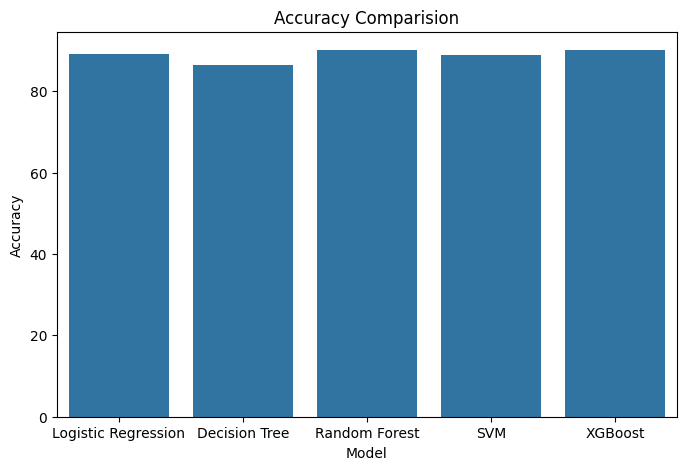

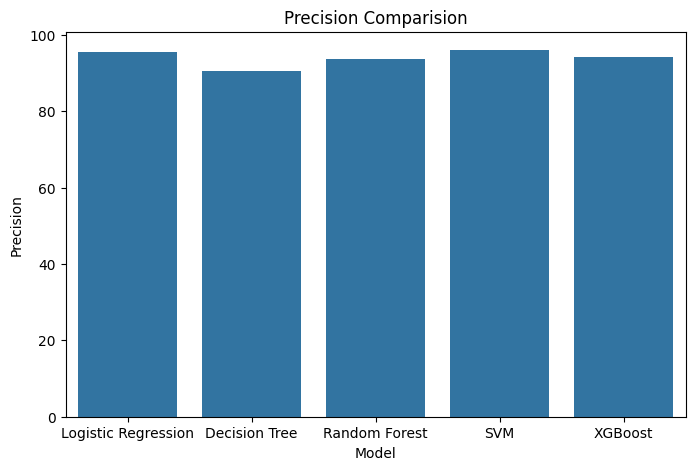

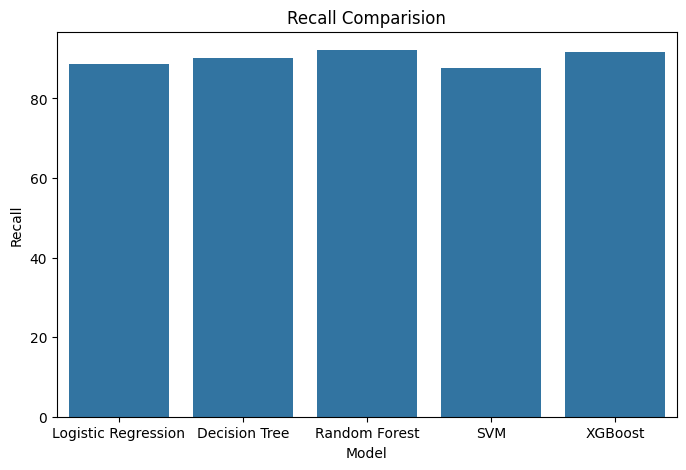

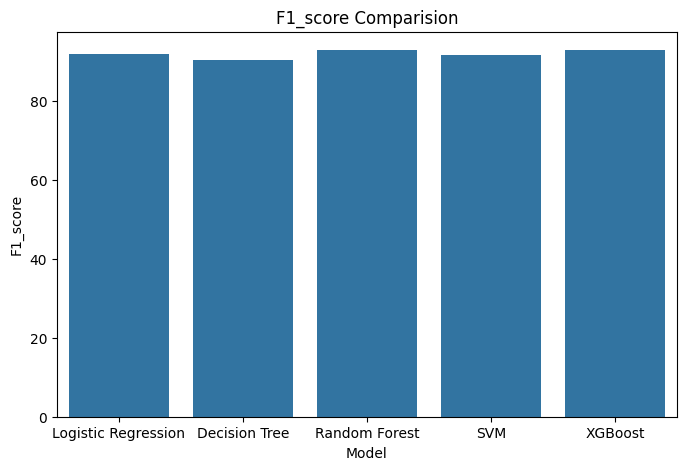

In [618]:
a=["Accuracy","Precision","Recall","F1_score"]
for i in a:
  plt.figure(figsize=(8,5))

  sns.barplot(data=comparison,x="Model",y=i)
  plt.title(f"{i} Comparision")
  plt.show()

# Final model with highest Accuracy

In [619]:
print("Final Model Accuracy :\n", comparison.loc[comparison["Accuracy"].idxmax()])

Final Model Accuracy :
 Model          XGBoost
Accuracy     90.116667
Precision    94.117647
Recall       91.581207
F1_score     92.832104
Name: 4, dtype: object


# Take  XGBoost
Because XGBoost give highest Accuracy



In [620]:
cm=confusion_matrix(test_y,xgb_pred)
cm

array([[1567,  240],
       [ 353, 3840]])

Text(50.722222222222214, 0.5, 'Predicted')

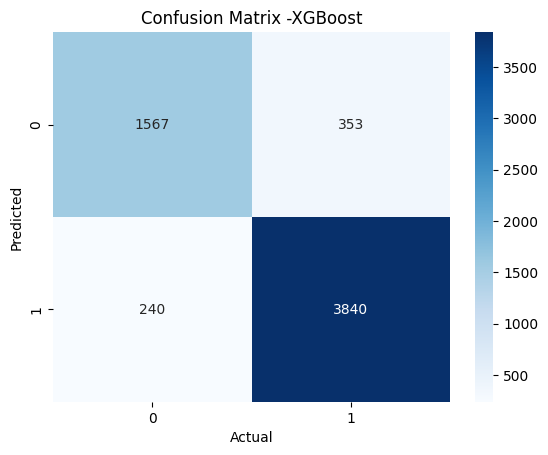

In [621]:
sns.heatmap(cm.T,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix -XGBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")

#Feature Importance



In [622]:

pd.DataFrame({"Features":x.columns,"importance":rf.feature_importances_})



,Features,importance
0,years_experience,0.324665
1,skills_match_score,0.148670
2,project_count,0.174733
3,resume_length,0.124485
4,github_activity,0.199934
5,education_level_High School,0.008012
6,education_level_Masters,0.010192
7,education_level_PhD,0.009309
